In [2]:
import yaml
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from pathlib import Path
from scipy.stats import norm
from scipy.fft import rfftfreq

from TraceSimulator import LongTraceSimulator
from TraceSimulator import NoiseGenerator
from OptimumFilter import OptimumFilter


In [3]:
def build_noise_psd(config, trace_samples):
    """Build PSD using the same shape+normalization pattern as ThresholdCalculation_OFProcessing."""
    ng = NoiseGenerator(config)
    freqs = rfftfreq(trace_samples, d=1.0 / ng.sampling_frequency)
    psd_shape = ng.spectrum(freqs)
    psd = psd_shape * config['noise_power'] * ng._normalize[ng.noise_type](freqs)
    return freqs, psd


In [4]:
def read_yaml_to_dict(file_path):
    with open(file_path, 'r') as file:
        config_dict = yaml.safe_load(file)
    return config_dict

config = read_yaml_to_dict('training_config.yaml')
templates = np.load('signalformation_templates_V2-1.npy')


In [5]:
noise_types = ["pink", "/ceph/dwong/delight_conf/new/noise_psd_xray.npy"]
noise_powers = range(0, 51, 1)

n_samples = 60_000
template_len = templates[0].size
noises = {}
noise_psds = {}
of_results = {}
for noise_type in tqdm(noise_types, desc="noise_type"):
    for noise_power in tqdm(noise_powers, desc="noise_power", leave=False):
        config['noise_type'] = noise_type
        config['noise_power'] = noise_power
        ng = NoiseGenerator(config)
        noisy_trace = ng.generate_noise(n_samples)
        noises[(noise_type, noise_power)] = noisy_trace

        freqs, psd = build_noise_psd(config, trace_samples=template_len)
        noise_psds[(noise_type, noise_power)] = (freqs, psd)

        of_qp = OptimumFilter(templates[1], psd, ng.sampling_frequency)
        of_uv = OptimumFilter(templates[0], psd, ng.sampling_frequency)

        amps_qp, chisq_qp = of_qp.sliding_fit(noisy_trace, hop=1, chisq_mode='all')
        amps_uv, chisq_uv = of_uv.sliding_fit(noisy_trace, hop=1, chisq_mode='all')
        of_results[(noise_type, noise_power)] = {
            'qp': (amps_qp, chisq_qp),
            'uv': (amps_uv, chisq_uv),
        }


noise_type:   0%|          | 0/2 [00:00<?, ?it/s]/home/dwong/DELight_mtr/trigger_study/vs_threshold/OptimumFilter.py:161: RuntimeWarning: divide by zero encountered in divide
  self._kernel_fft = self._template_fft.conjugate() / self._noise_psd_unfolded
/home/dwong/DELight_mtr/trigger_study/vs_threshold/OptimumFilter.py:161: RuntimeWarning: invalid value encountered in divide
  self._kernel_fft = self._template_fft.conjugate() / self._noise_psd_unfolded
/home/dwong/DELight_mtr/trigger_study/vs_threshold/OptimumFilter.py:165: RuntimeWarning: invalid value encountered in divide
  self._filter_kernel = self._kernel_fft / self._kernel_normalization
/home/dwong/DELight_mtr/trigger_study/vs_threshold/OptimumFilter.py:170: RuntimeWarning: divide by zero encountered in divide
  self._inv_noise_psd_unf = np.ascontiguousarray((1.0 / self._noise_psd_unfolded).astype(np.float64))
noise_type:  50%|█████     | 1/2 [00:26<00:26, 26.05s/it]/home/dwong/DELight_mtr/trigger_study/vs_threshold/OptimumFilt

pink noise power 1.75: sigma_qp=0.581095, sigma_uv=0.469716, samples=63617/63617
pink noise power 6.73: sigma_qp=1.19541, sigma_uv=0.941077, samples=63617/63617
pink noise power 16.60: sigma_qp=1.813, sigma_uv=1.45092, samples=63617/63617
pink noise power 69.13: sigma_qp=3.70415, sigma_uv=2.96408, samples=63617/63617


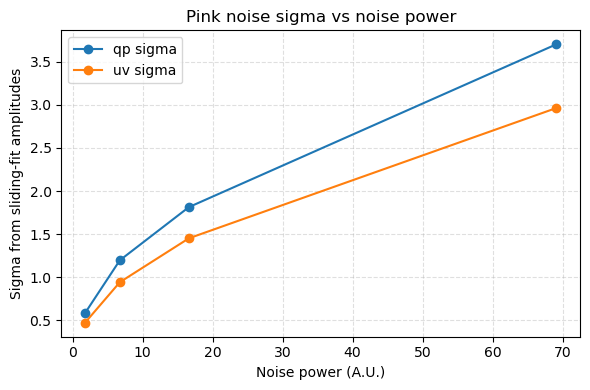

In [6]:
# Pink noise sigma from sliding-fit amplitudes on long noise traces
pink_noise_powers = [1.75, 6.73, 16.60, 69.13]

n_samples_long = 80_000
template_len = templates[0].size

pink_sigma_qp = {}
pink_sigma_uv = {}

for noise_power in pink_noise_powers:
    config['noise_type'] = 'pink'
    config['noise_power'] = float(noise_power)

    ng = NoiseGenerator(config)
    noisy_trace = ng.generate_noise(n_samples_long)

    _, psd = build_noise_psd(config, trace_samples=template_len)
    of_qp = OptimumFilter(templates[1], psd, ng.sampling_frequency)
    of_uv = OptimumFilter(templates[0], psd, ng.sampling_frequency)

    amps_qp, _ = of_qp.sliding_fit(noisy_trace, hop=1, chisq_mode='none')
    amps_uv, _ = of_uv.sliding_fit(noisy_trace, hop=1, chisq_mode='none')

    amps_qp = np.asarray(amps_qp)
    amps_uv = np.asarray(amps_uv)
    amps_qp = amps_qp[np.isfinite(amps_qp)]
    amps_uv = amps_uv[np.isfinite(amps_uv)]

    sigma_qp = np.nan
    sigma_uv = np.nan
    if amps_qp.size:
        _, sigma_qp = norm.fit(amps_qp)
    if amps_uv.size:
        _, sigma_uv = norm.fit(amps_uv)

    pink_sigma_qp[noise_power] = float(sigma_qp)
    pink_sigma_uv[noise_power] = float(sigma_uv)

    print(
        f"pink noise power {noise_power:.2f}: "
        f"sigma_qp={sigma_qp:.6g}, sigma_uv={sigma_uv:.6g}, "
        f"samples={amps_qp.size}/{amps_uv.size}"
    )

# Quick check plot
plt.figure(figsize=(6, 4))
plt.plot(list(pink_sigma_qp.keys()), list(pink_sigma_qp.values()), marker='o', label='qp sigma')
plt.plot(list(pink_sigma_uv.keys()), list(pink_sigma_uv.values()), marker='o', label='uv sigma')
plt.xlabel('Noise power (A.U.)')
plt.ylabel('Sigma from sliding-fit amplitudes')
plt.title('Pink noise sigma vs noise power')
plt.grid(True, which='both', linestyle='--', alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()


pink qp:
  0.68 eV -> noise power [2.06178014]
  1.1 eV -> noise power [6.50391609]
  1.8 eV -> noise power [15.9385483]
  3.5 eV -> noise power [58.99972147]
pink uv:
  0.68 eV -> noise power [3.74410534]
  1.1 eV -> noise power [9.72159847]
  1.8 eV -> noise power [24.29645441]
  3.5 eV -> noise power [70.56486485]
/ceph/dwong/delight_conf/new/noise_psd_xray.npy qp:
  0.68 eV -> noise power [11.97469143]
  1.1 eV -> noise power [30.91683988]
  1.8 eV -> noise power [68.06783608]
  3.5 eV -> noise power [99.34015238]
/ceph/dwong/delight_conf/new/noise_psd_xray.npy uv:
  0.68 eV -> noise power [9.49269634]
  1.1 eV -> noise power [23.80887394]
  1.8 eV -> noise power [59.32815919]
  3.5 eV -> noise power [92.08486127]


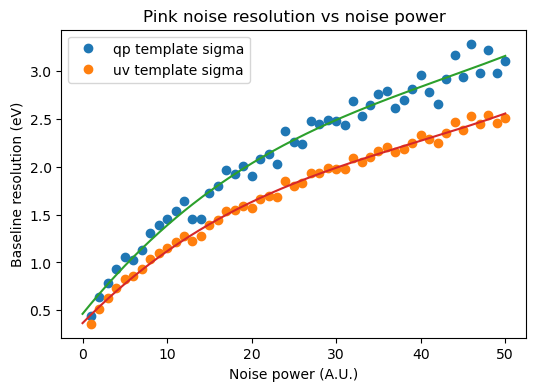

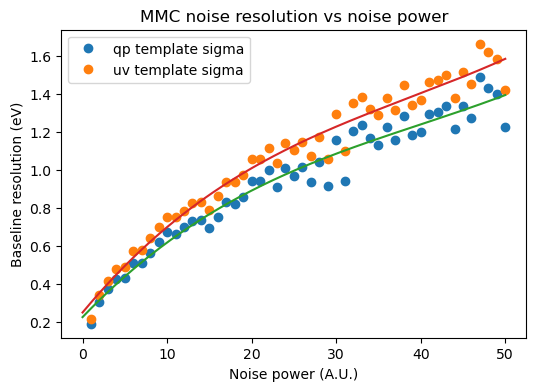

In [7]:
# Fit Gaussian sigma for each noise type and power, for qp and uv amplitudes
noise_list = list(noise_types)
power_list = list(noise_powers)
sigma_qp = np.full((len(noise_list), len(power_list)), np.nan)
sigma_uv = np.full((len(noise_list), len(power_list)), np.nan)

for i, noise_type in enumerate(noise_list):
    for j, noise_power in enumerate(power_list):
        amps_qp, _ = of_results[(noise_type, noise_power)]['qp']
        amps_uv, _ = of_results[(noise_type, noise_power)]['uv']

        amps_qp = np.asarray(amps_qp)
        amps_uv = np.asarray(amps_uv)
        amps_qp = amps_qp[np.isfinite(amps_qp)]
        amps_uv = amps_uv[np.isfinite(amps_uv)]

        if amps_qp.size:
            _, sigma_qp[i, j] = norm.fit(amps_qp)
        if amps_uv.size:
            _, sigma_uv[i, j] = norm.fit(amps_uv)

poly_deg = 3
x = np.asarray(power_list, dtype=float)
x_fit = np.linspace(x.min(), x.max(), 300)
target_energies = [0.68, 1.1, 1.8, 3.5]

def solve_noise_power(coeffs, targets):
    results = {}
    for t in targets:
        roots = np.roots(np.poly1d(coeffs) - t)
        real_roots = roots[np.isreal(roots)].real
        results[t] = np.sort(real_roots)
    return results

for i, noise_type in enumerate(noise_list):
    plt.figure(figsize=(6, 4))
    plt.plot(power_list, sigma_qp[i], marker='o', linestyle='none', label='qp template sigma')
    plt.plot(power_list, sigma_uv[i], marker='o', linestyle='none', label='uv template sigma')

    mask_qp = np.isfinite(sigma_qp[i])
    mask_uv = np.isfinite(sigma_uv[i])

    coeffs_qp = None
    coeffs_uv = None
    if mask_qp.sum() > poly_deg:
        coeffs_qp = np.polyfit(x[mask_qp], sigma_qp[i][mask_qp], poly_deg)
        plt.plot(x_fit, np.polyval(coeffs_qp, x_fit), '-', label='_nolegend_')
    if mask_uv.sum() > poly_deg:
        coeffs_uv = np.polyfit(x[mask_uv], sigma_uv[i][mask_uv], poly_deg)
        plt.plot(x_fit, np.polyval(coeffs_uv, x_fit), '-', label='_nolegend_')

    plt.xlabel('Noise power (A.U.)')
    plt.ylabel('Baseline resolution (eV)')
    if noise_type == 'pink':
        title = 'Pink noise resolution vs noise power'
    else:
        title = 'MMC noise resolution vs noise power'
    plt.title(title)
    plt.legend()

    if coeffs_qp is not None:
        sol_qp = solve_noise_power(coeffs_qp, target_energies)
        print(f'{noise_type} qp:')
        for t in target_energies:
            vals = sol_qp[t]
            print(f'  {t} eV -> noise power {vals}')
    if coeffs_uv is not None:
        sol_uv = solve_noise_power(coeffs_uv, target_energies)
        print(f'{noise_type} uv:')
        for t in target_energies:
            vals = sol_uv[t]
            print(f'  {t} eV -> noise power {vals}')
